# **Banking Campaign Analysis**

## **Data Preprocessing**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import nltk
import re
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("prakharrathi25/banking-dataset-marketing-targets")
path = os.path.join(path, os.listdir(path)[0])

print("Path to dataset files:", path)

100%|██████████| 576k/576k [00:00<00:00, 30.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/prakharrathi25/banking-dataset-marketing-targets/versions/2/train.csv


In [ ]:
os.listdir(os.path.dirname(path))

['train.csv', 'test.csv']

In [ ]:
#Loading the dataset

df = pd.read_csv(path, sep=";")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


## **Explorative Data Analysis**

In [ ]:
#Analysing the dataset

# 1. Columns of datset
print(df.columns)
# 2. Shape of dataset
print(df.shape)


Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')
(45211, 17)


In [ ]:
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
cols = ['job', 'marital','education','default','housing','loan',
        'contact','poutcome','y']

label_features = {col: df[col].unique() for col in cols}

for i in label_features:
  print(i)
  for j, k in enumerate(label_features[i]):
    df[i] = df[i].replace(k, j)
    print(str(k) + ":" + str(j))
  print("\n")

job
management:0
technician:1
entrepreneur:2
blue-collar:3
unknown:4
retired:5
admin.:6
services:7
self-employed:8
unemployed:9
housemaid:10
student:11


marital
married:0
single:1
divorced:2


education
tertiary:0
secondary:1
unknown:2
primary:3


default


/tmp/ipykernel_1076/3253068717.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[i] = df[i].replace(k, j)


no:0
yes:1


housing
yes:0
no:1


loan
no:0
yes:1


contact
unknown:0
cellular:1
telephone:2


poutcome
unknown:0
failure:1
other:2
success:3


y
no:0
yes:1




In [ ]:
df['month'] = df['month'].replace({'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12})

/tmp/ipykernel_1076/3508438999.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['month'] = df['month'].replace({'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12})


In [ ]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,0,0,0,0,2143,0,0,0,5,5,261,1,-1,0,0,0
1,44,1,1,1,0,29,0,0,0,5,5,151,1,-1,0,0,0
2,33,2,0,1,0,2,0,1,0,5,5,76,1,-1,0,0,0
3,47,3,0,2,0,1506,0,0,0,5,5,92,1,-1,0,0,0
4,33,4,1,2,0,1,1,0,0,5,5,198,1,-1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,1,0,0,0,825,1,0,1,17,11,977,3,-1,0,0,1
45207,71,5,2,3,0,1729,1,0,1,17,11,456,2,-1,0,0,1
45208,72,5,0,1,0,5715,1,0,1,17,11,1127,5,184,3,3,1
45209,57,3,0,1,0,668,1,0,2,17,11,508,4,-1,0,0,0


In [ ]:
print(df.describe())

                age           job       marital     education       default  \
count  45211.000000  45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210      3.526133      0.513238      1.049944      0.018027   
std       10.618762      3.098343      0.692948      0.968986      0.133049   
min       18.000000      0.000000      0.000000      0.000000      0.000000   
25%       33.000000      1.000000      0.000000      0.000000      0.000000   
50%       39.000000      3.000000      0.000000      1.000000      0.000000   
75%       48.000000      6.000000      1.000000      1.000000      0.000000   
max       95.000000     11.000000      2.000000      3.000000      1.000000   

             balance       housing          loan       contact           day  \
count   45211.000000  45211.000000  45211.000000  45211.000000  45211.000000   
mean     1362.272058      0.444162      0.160226      0.776293     15.806419   
std      3044.765829      0.496878      0.366820

## **Data Visualisation**

In [ ]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,0,0,0,0,2143,0,0,0,5,5,261,1,-1,0,0,0
1,44,1,1,1,0,29,0,0,0,5,5,151,1,-1,0,0,0
2,33,2,0,1,0,2,0,1,0,5,5,76,1,-1,0,0,0
3,47,3,0,2,0,1506,0,0,0,5,5,92,1,-1,0,0,0
4,33,4,1,2,0,1,1,0,0,5,5,198,1,-1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,1,0,0,0,825,1,0,1,17,11,977,3,-1,0,0,1
45207,71,5,2,3,0,1729,1,0,1,17,11,456,2,-1,0,0,1
45208,72,5,0,1,0,5715,1,0,1,17,11,1127,5,184,3,3,1
45209,57,3,0,1,0,668,1,0,2,17,11,508,4,-1,0,0,0


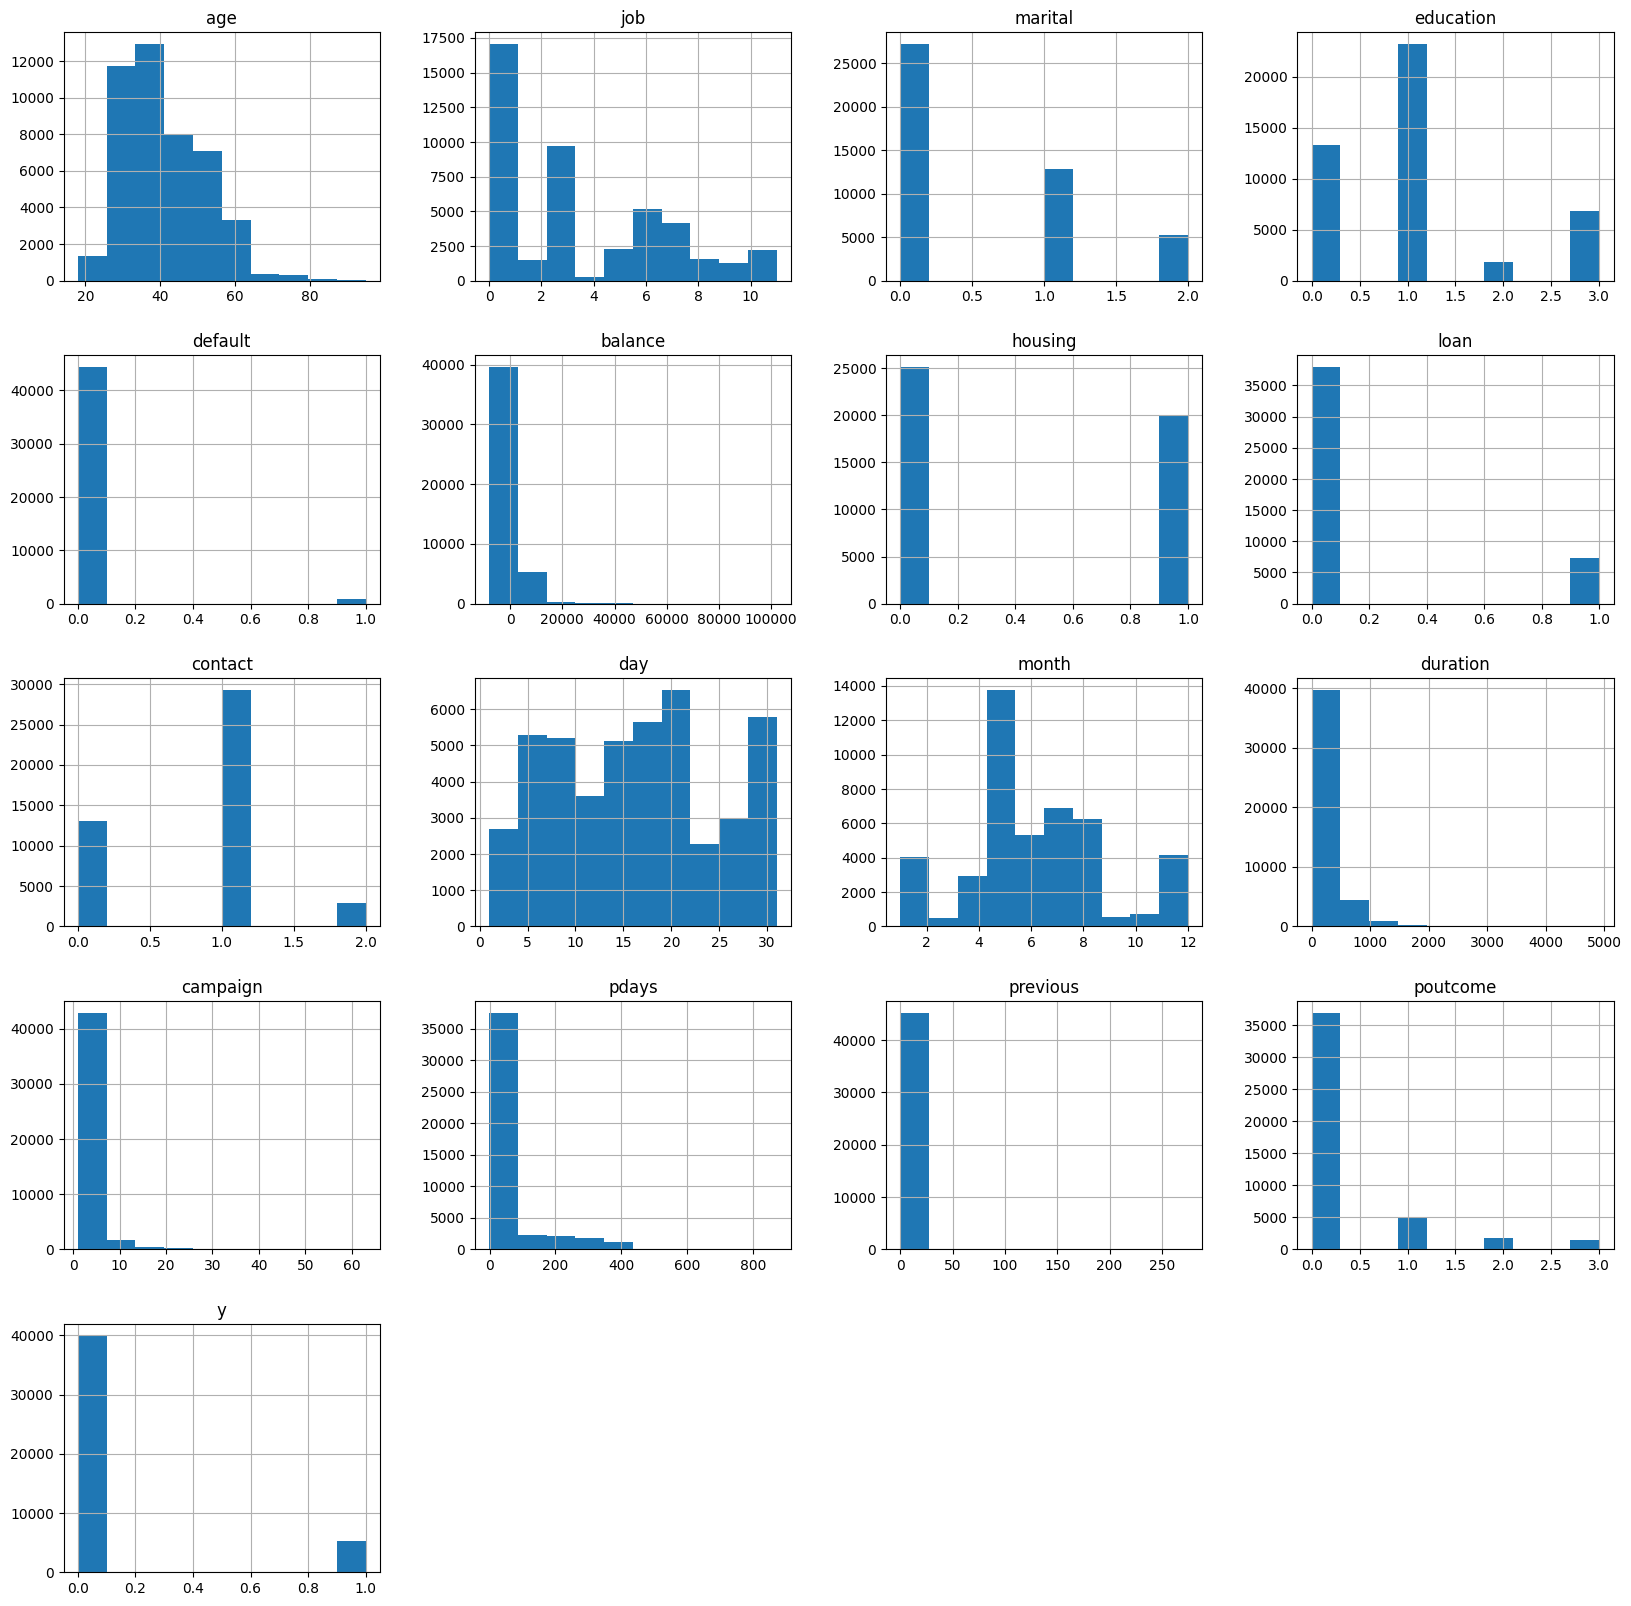

In [ ]:
df.hist(figsize=(20,20))
plt.show()

0 : management
1 : technician
2 : entrepreneur
3 : blue-collar
4 : unknown
5 : retired
6 : admin.
7 : services
8 : self-employed
9 : unemployed
10 : housemaid
11 : student




<Axes: xlabel='job', ylabel='count'>

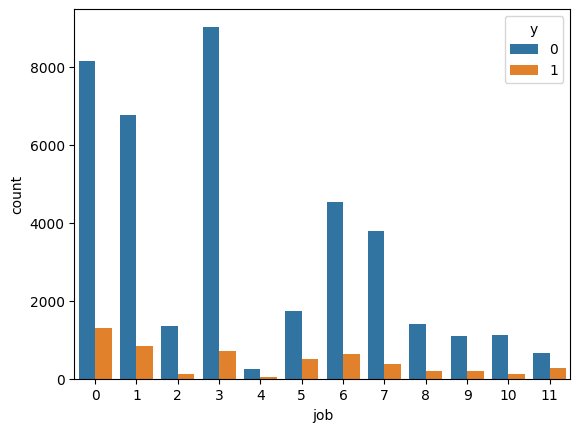

In [ ]:
# Count of jobs and the count of persons who subscribed to a deposit plan

for i,j in enumerate(label_features['job']):
  print(str(i) + " : " + str(j))

print('\n')
sns.countplot(x='job', hue='y', data=df)

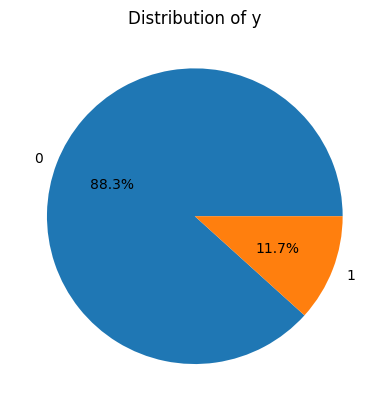

In [ ]:
y_counts = df['y'].value_counts()
plt.pie(y_counts, labels=y_counts.index, autopct='%1.1f%%')
plt.title('Distribution of y')
plt.show()

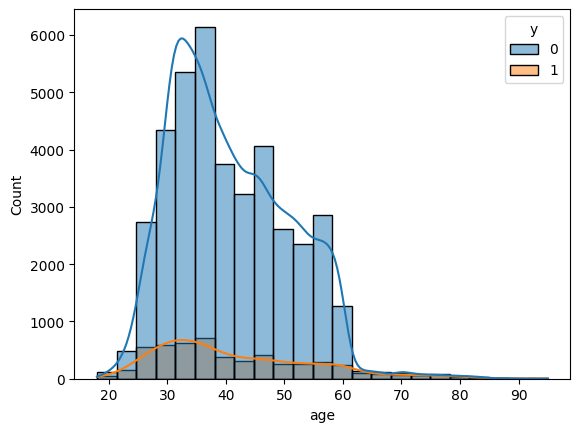

In [ ]:
sns.histplot(data=df, x='age', kde=True, bins=23, hue='y')  # histogram + KDE
plt.show()

In [ ]:
# Fisher score is a scoring method used to rank columns to determine which feature can seperate the classes efficiently
# Larger the fisher score, the good the feature is to seperate the classes

#Fisher score = (uA - uB)**2 / (varA + varB)

def fisher_score_binary_class(ds, index):
  A = ds[ds.iloc[:,-1] == 0].iloc[:,index]
  B = ds[ds.iloc[:,-1] == 1].iloc[:,index]
  uA = np.mean(A)
  uB = np.mean(B)
  varA = np.var(A, ddof=1)
  varB = np.var(B, ddof =1)
  fisher_score = (uA - uB)**2 / (varA + varB)
  return fisher_score

bank_fisher_score = []
for i in range(0, len(df.columns) - 1):
  bank_fisher_score.append((i, fisher_score_binary_class(df, i)))

bank_fisher_score.sort(key=lambda x: x[1], reverse=True)
for i,j in bank_fisher_score:
    print(df.columns[i] + " : " + str(j))

duration : 0.5070259677900119
poutcome : 0.18421898564234862
contact : 0.10250202399971749
housing : 0.09735459890851632
pdays : 0.04438124284604705
previous : 0.03845006836122099
campaign : 0.03549354093974471
loan : 0.02705772622129813
education : 0.017321926304852513
balance : 0.01187255100050336
marital : 0.009350824615745573
day : 0.0038190641942037777
default : 0.0030237105743201047
age : 0.002417799798298794
job : 0.0022389561476135796
month : 0.00149186018758521


<Axes: xlabel='duration', ylabel='balance'>

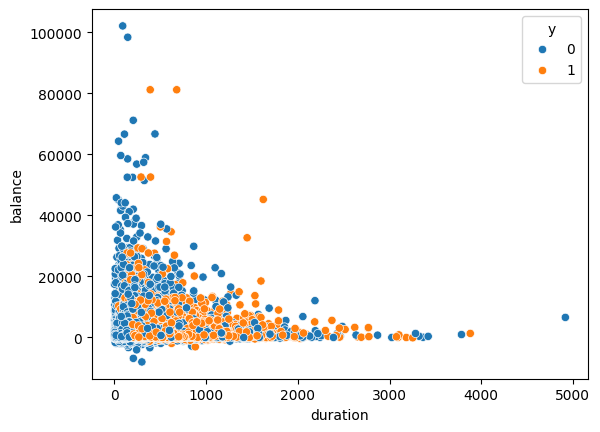

In [ ]:
sns.scatterplot(x='duration', y='balance', hue='y', data=df)

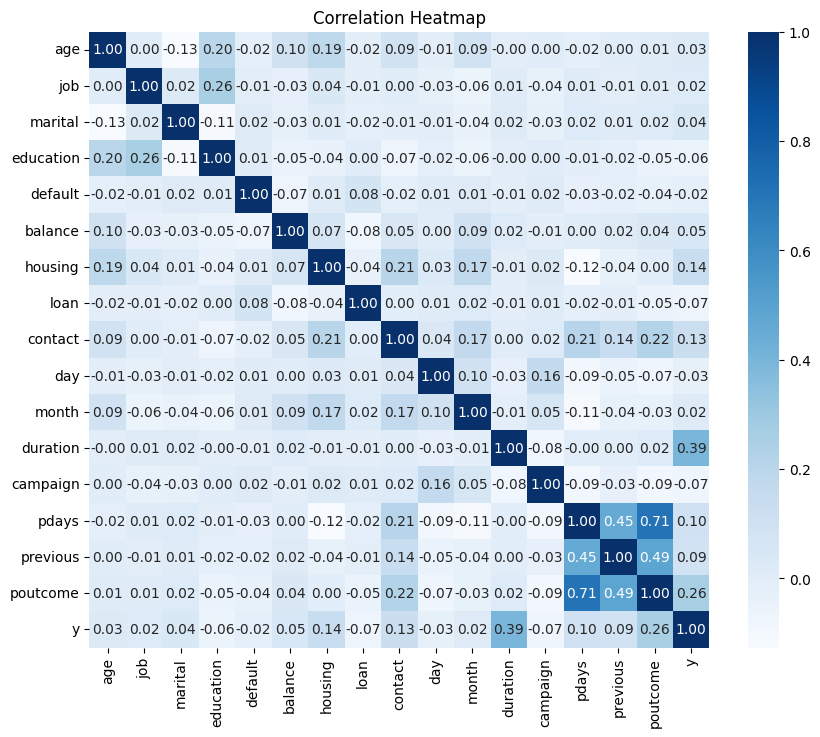

In [ ]:
corr_matrix = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,      # show correlation values
            fmt=".2f",       # 2 decimal places
            cmap="Blues", # color map
            cbar=True)
plt.title("Correlation Heatmap")
plt.show()

<Axes: xlabel='pdays', ylabel='poutcome'>

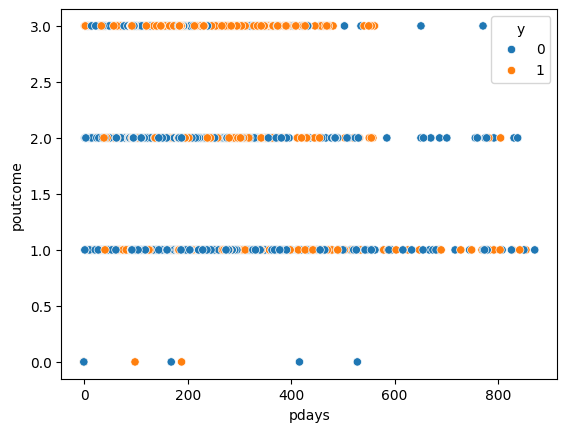

In [ ]:
sns.scatterplot(x='pdays', y='poutcome', hue='y', data=df)

## **Data Standardisation**

In [ ]:
df_0 = df[df['y'] == 0]
df_1 = df[df['y'] == 1]

In [ ]:
print(X.shape)
print(df[df['y'] == 0].shape)
print(df[df['y'] == 1].shape)

(45211, 16)
(39922, 17)
(5289, 17)


In [ ]:
df_0_sampled = df_0.sample(n=5289, random_state=42)
df_1_sampled = df_1
df_combined = pd.concat([df_0_sampled, df_1_sampled])

In [ ]:
X = df_combined.drop(columns=['y'], axis=1)
Y = df_combined['y']


In [ ]:
X_train = X
Y_train = Y

In [ ]:
path = os.path.dirname(path)

'/root/.cache/kagglehub/datasets/prakharrathi25/banking-dataset-marketing-targets/versions/2'

In [ ]:
path = os.path.join(path, os.listdir(path)[1])
print(path)

/root/.cache/kagglehub/datasets/prakharrathi25/banking-dataset-marketing-targets/versions/2/test.csv


In [ ]:
test_df = pd.read_csv(path, sep=';')
test_df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [ ]:
test_df = test_df.replace({
    "job": {
        "management": 0,
        "technician": 1,
        "entrepreneur": 2,
        "blue-collar": 3,
        "unknown": 4,
        "retired": 5,
        "admin.": 6,
        "services": 7,
        "self-employed": 8,
        "unemployed": 9,
        "housemaid": 10,
        "student": 11
    },
    "marital": {
        "married": 0,
        "single": 1,
        "divorced": 2
    },
    "education": {
        "tertiary": 0,
        "secondary": 1,
        "unknown": 2,
        "primary": 3
    },
    "default": {
        "no": 0,
        "yes": 1
    },
    "housing": {
        "yes": 0,
        "no": 1
    },
    "loan": {
        "no": 0,
        "yes": 1
    },
    "contact": {
        "unknown": 0,
        "cellular": 1,
        "telephone": 2
    },
    "poutcome": {
        "unknown": 0,
        "failure": 1,
        "other": 2,
        "success": 3
    },
    "y": {
        "no": 0,
        "yes": 1
    }
})

/tmp/ipykernel_1076/181523516.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df = test_df.replace({


In [ ]:
test_df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,9,0,3,0,1787,1,0,1,19,oct,79,1,-1,0,0,0
1,33,7,0,1,0,4789,0,1,1,11,may,220,1,339,4,1,0
2,35,0,1,0,0,1350,0,0,1,16,apr,185,1,330,1,1,0
3,30,0,0,0,0,1476,0,1,0,3,jun,199,4,-1,0,0,0
4,59,3,0,1,0,0,0,0,0,5,may,226,1,-1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,7,0,1,0,-333,0,0,1,30,jul,329,5,-1,0,0,0
4517,57,8,0,0,1,-3313,0,1,0,9,may,153,1,-1,0,0,0
4518,57,1,0,1,0,295,1,0,1,19,aug,151,11,-1,0,0,0
4519,28,3,0,1,0,1137,1,0,1,6,feb,129,4,211,3,2,0


In [ ]:
test_df['month'] = test_df['month'].replace({'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12})

/tmp/ipykernel_1076/3546905140.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['month'] = test_df['month'].replace({'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6, 'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12})


In [ ]:
test_df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,9,0,3,0,1787,1,0,1,19,10,79,1,-1,0,0,0
1,33,7,0,1,0,4789,0,1,1,11,5,220,1,339,4,1,0
2,35,0,1,0,0,1350,0,0,1,16,4,185,1,330,1,1,0
3,30,0,0,0,0,1476,0,1,0,3,6,199,4,-1,0,0,0
4,59,3,0,1,0,0,0,0,0,5,5,226,1,-1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,7,0,1,0,-333,0,0,1,30,7,329,5,-1,0,0,0
4517,57,8,0,0,1,-3313,0,1,0,9,5,153,1,-1,0,0,0
4518,57,1,0,1,0,295,1,0,1,19,8,151,11,-1,0,0,0
4519,28,3,0,1,0,1137,1,0,1,6,2,129,4,211,3,2,0


In [ ]:
X_test = test_df.drop(columns=['y'], axis=1)
Y_test = test_df['y']

In [ ]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## **Model Evaluation**

**Logistic Regression**

In [ ]:
lg_model = LogisticRegression(max_iter=1000)
lg_model.fit(X_train, Y_train)
X_train_pred = lg_model.predict(X_train)
X_test_pred = lg_model.predict(X_test)
print('Training Accuracy : ', accuracy_score(X_train_pred, Y_train))
print('Testing Accuracy : ', accuracy_score(X_test_pred, Y_test))

Training Accuracy :  0.8022310455662696
Testing Accuracy :  0.8155275381552753


**Random Forest Classifier**

In [ ]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, Y_train)
X_train_pred = rf_model.predict(X_train)
X_test_pred = rf_model.predict(X_test)
print('Training Accuracy : ', accuracy_score(X_train_pred, Y_train))
print('Testing Accuracy : ', accuracy_score(X_test_pred, Y_test))


Training Accuracy :  1.0
Testing Accuracy :  0.8613138686131386


**Support Vector Classifier**

In [ ]:
from sklearn.svm import SVC
kernel = ['linear', 'rbf', 'poly', 'sigmoid']
for k in kernel:
  svc_model = SVC(kernel = k)
  svc_model.fit(X_train, Y_train)
  X_train_pred = svc_model.predict(X_train)
  X_test_pred = svc_model.predict(X_test)
  print('Training Accuracy : ', accuracy_score(X_train_pred, Y_train))
  print('Testing Accuracy : ', accuracy_score(X_test_pred, Y_test))

Training Accuracy :  0.8028927963698241
Testing Accuracy :  0.8133156381331563
Training Accuracy :  0.8521459633200983
Testing Accuracy :  0.8106613581066135
Training Accuracy :  0.8449612403100775
Testing Accuracy :  0.8252598982525989
Training Accuracy :  0.7053318207600681
Testing Accuracy :  0.7142225171422252


**K Nearest Neighbour**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)

X_train_pred = knn.predict(X_train)
X_test_pred = knn.predict(X_test)

print('k : ', 5)
print("Training Accuracy :", accuracy_score(Y_train, X_train_pred))
print("Testing Accuracy  :", accuracy_score(Y_test, X_test_pred))

knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train, Y_train)

X_train_pred = knn.predict(X_train)
X_test_pred = knn.predict(X_test)

print('k : ', 4)
print("Training Accuracy :", accuracy_score(Y_train, X_train_pred))
print("Testing Accuracy  :", accuracy_score(Y_test, X_test_pred))

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, Y_train)

X_train_pred = knn.predict(X_train)
X_test_pred = knn.predict(X_test)

print('k : ', 3)
print("Training Accuracy :", accuracy_score(Y_train, X_train_pred))
print("Testing Accuracy  :", accuracy_score(Y_test, X_test_pred))

knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train, Y_train)

X_train_pred = knn.predict(X_train)
X_test_pred = knn.predict(X_test)

print('k : ', 6)
print("Training Accuracy :", accuracy_score(Y_train, X_train_pred))
print("Testing Accuracy  :", accuracy_score(Y_test, X_test_pred))

k :  5
Training Accuracy : 0.8559273964832672
Testing Accuracy  : 0.8237115682371157
k :  4
Training Accuracy : 0.8468519568916619
Testing Accuracy  : 0.8597655385976554
k :  3
Training Accuracy : 0.8854225751559841
Testing Accuracy  : 0.820836098208361
k :  6
Training Accuracy : 0.8321989033843826
Testing Accuracy  : 0.8502543685025437
